## Mini-Project : Data Analysis for Marketing Strategy

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/BootGenAI/US_Superstore_data.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
#state with the most sales
df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(1)

,Sales
State,
California,457687.6315


In [16]:
#The difference between New York and California in terms of sales and profit
ny_sales = df[df["State"] == "New York"]["Sales"].sum().round(2)
ca_sales = df[df["State"] == "California"]["Sales"].sum().round(2)

print("New York Sales:", ny_sales)
print("California Sales:", ca_sales)

New York Sales: 310876.27
California Sales: 457687.63


In [20]:
#outstanding customer in New York
outstanding_customer = df[df["State"] == "New York"].groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
outstanding_customer.head(1)


,Sales
Customer Name,
Tom Ashbrook,13723.498


In [23]:
#differences among states in profitability
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

print(state_profit)


State
California              76381.3871
New York                74038.5486
Washington              33402.6517
Michigan                24463.1876
Virginia                18597.9504
Indiana                 18382.9363
Georgia                 16250.0433
Kentucky                11199.6966
Minnesota               10823.1874
Delaware                 9977.3748
New Jersey               9772.9138
Wisconsin                8401.8004
Rhode Island             7285.6293
Maryland                 7031.1788
Massachusetts            6785.5016
Missouri                 6436.2105
Alabama                  5786.8253
Oklahoma                 4853.9560
Arkansas                 4008.6871
Connecticut              3511.4918
Nevada                   3316.7659
Mississippi              3172.9762
Utah                     2546.5335
Vermont                  2244.9783
Louisiana                2196.1023
Nebraska                 2037.0942
Montana                  1833.3285
South Carolina           1769.0566
New Hampshire 

In [27]:
#Pareto Principle
#Aggregate profit/customer
profit_customer = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

print(profit_customer)


Customer Name
Tamara Chand      8981.3239
Raymond Buch      6976.0959
Sanjit Chand      5757.4119
Hunter Lopez      5622.4292
Adrian Barton     5444.8055
                    ...    
Henry Goldwyn    -2797.9635
Sharelle Roach   -3333.9144
Luke Foster      -3583.9770
Grant Thornton   -4108.6589
Cindy Stewart    -6626.3895
Name: Profit, Length: 793, dtype: float64


In [29]:
#Calculate cummulatice contribution
#  profit
total_profit = profit_customer.sum()

# Cumulative profit share
cumulative_share = profit_customer.cumsum() / total_profit

In [30]:
#identify 20% customers

n_customers = len(profit_customer)

# Top 20% cutoff
top_20pct = int(0.2 * n_customers)

# Profit share of top 20% customers
pareto_share = profit_customer.head(top_20pct).sum() / total_profit

print("Top 20% customers contribute:", pareto_share)

Top 20% customers contribute: 0.8142587496747005


 while pareto_share ≈ 0.8 (80%), then the Pareto Principle holds in my dataset.

In [39]:
# city‑level profitability analysis
#Top 20 cities by sales
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False)
top20_sales = city_sales.head(20)
print(top20_sales)

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64


In [37]:
#Top 20 cities by profit
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False)
top20_profit = city_profit.head(20)
print(top20_profit)

City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64


In [40]:
#Compare Sales vs Profit
comparison = pd.DataFrame({
    "Sales": city_sales,
    "Profit": city_profit
})

# Filter only top 20 by either Sales or Profit
top_cities = comparison.loc[
    comparison.index.isin(top20_sales.index) | comparison.index.isin(top20_profit.index)
]

print(top_cities)

                     Sales      Profit
City                                  
Arlington       20214.5320   4169.6969
Atlanta         17197.8400   6993.6629
Burlington      21668.0820  -3622.8772
Chicago         48539.5410  -6654.5688
Columbia        25283.3240   5606.1167
Columbus        38706.2430   5897.1013
Dallas          20131.9322  -2846.5257
Detroit         42446.9440  13181.7908
Henderson       17549.0680   4911.8609
Houston         64504.7604 -10153.5485
Jackson         24963.8580   7581.6828
Jacksonville    44713.1830  -2323.8350
Lafayette       25036.2000  10018.3876
Lakewood        18192.0470   3234.0278
Los Angeles    175851.3410  30440.7579
Milwaukee       11410.2200   2793.0851
Minneapolis     16870.5400   6824.5846
New York City  256368.1610  62036.9837
Newark          28576.1190   5793.7588
Philadelphia   109077.0130 -13837.7674
Providence      15980.6500   5505.6569
Richmond        18137.9300   5567.2486
San Antonio     21843.5280  -7299.0502
San Diego       47521.029

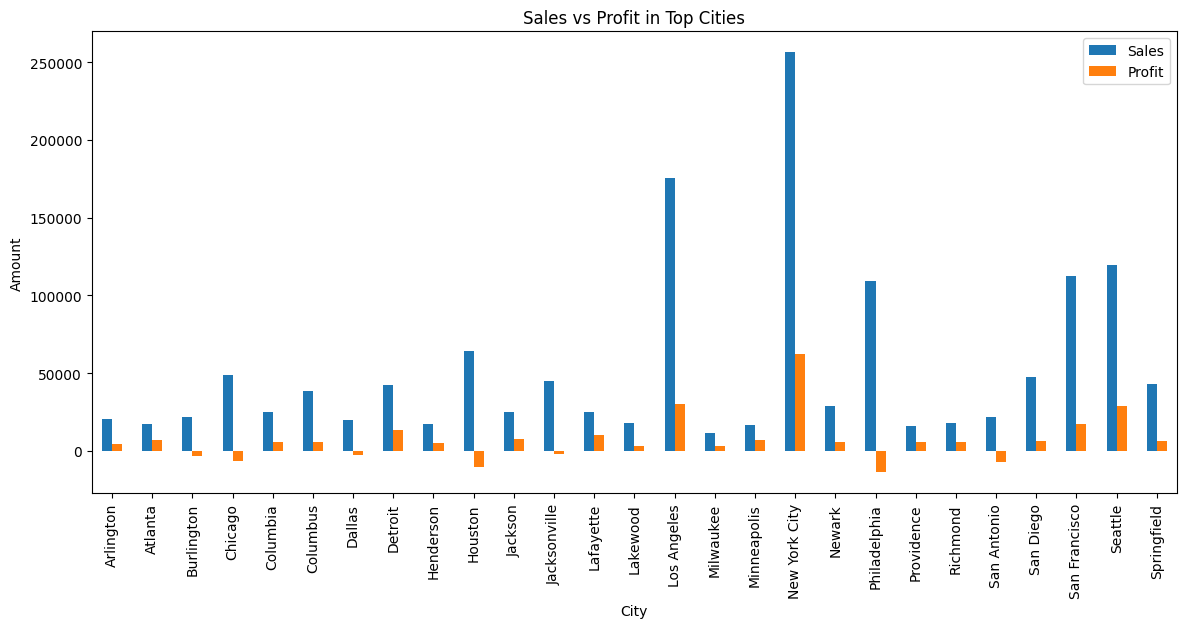

In [42]:
import matplotlib.pyplot as plt

# Combined
top_cities.plot(kind='bar', figsize=(14,6))
plt.title("Sales vs Profit in Top Cities")
plt.ylabel("Amount")
plt.show()

Yes, there are big differences among cities in profitability.

NYC is the clear leader in both sales and profit.

Some cities with high sales are inefficient (negative profit)

In [43]:
#top 20 customers by Sales
customer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
top20_customer_sales = customer_sales.head(20)
print(top20_customer_sales)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


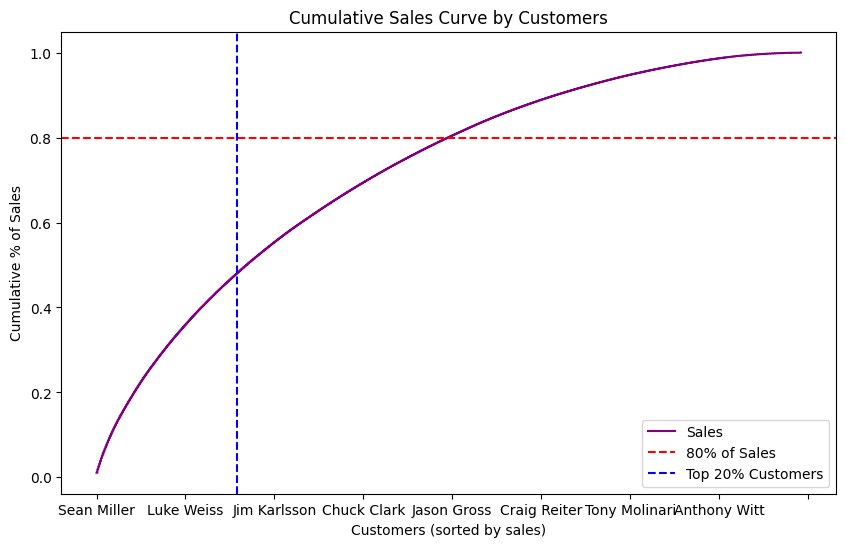

In [45]:
#Plot the cumulatice curve in sales by customers
customer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)

#compute
total_sales = customer_sales.sum()
cumulative_share = customer_sales.cumsum() / total_sales

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
cumulative_share.plot(drawstyle='steps-post', color='purple')
plt.axhline(0.8, color='red', linestyle='--', label='80% of Sales')
plt.axvline(int(0.2*len(customer_sales)), color='blue', linestyle='--', label='Top 20% Customers')
plt.title("Cumulative Sales Curve by Customers")
plt.xlabel("Customers (sorted by sales)")
plt.ylabel("Cumulative % of Sales")
plt.legend()
plt.show()


Yes, the Pareto Principle applies to customers and sales in this dataset.  
By plotting the cumulative sales curve, we observe that approximately 20% of customers contribute to nearly 80% of total sales

### Decision 

Focus marketing resources on **New York City, Seattle, Los Angeles, San Francisco, Detroit, and Lafayette**, these are proven profitable hubs. Monitor and optimize strategies in high‑sales but low‑margin states/cities (Philadelphia, Houston, Chicago), and selectively invest in smaller profitable markets for efficient growth.